# OCR Reflow with Layout Analysis

This notebook demonstrates how to use the OCR reflow package with layout analysis to process book pages.

## Overview

The layout analysis detects different content types:
- **Plain text** and **titles**: Reflowed with proper line wrapping
- **Figures** and **figure captions**: Grouped and placed as-is (zoomed)
- **Tables** and **table captions/footnotes**: Placed as-is (zoomed)
- **Formulas** and **formula captions**: Grouped and placed as-is (zoomed)
- **Abandon**: Headers/footers (ignored)

## Setup

In [1]:
import sys
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Add src directory to path
project_root = Path.cwd().parent
src_path = project_root / "src"
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

# Import ocr_reflow functions
from ocr_reflow.main import process_document_with_layout
from ocr_reflow.layout import layout as analyze_layout

print("✓ Imports successful")

✓ Imports successful


## Configure Input Image

In [2]:
# Set your input image path here
input_image = project_root / "images" / "dvurog_p007.png"

# Alternative images to try:
# input_image = project_root / "images" / "kf_p015.png"
# input_image = Path("out13.png")  # Use a notebook image

if not input_image.exists():
    print(f"❌ Image not found: {input_image}")
else:
    print(f"✓ Using image: {input_image}")

✓ Using image: /home/sergey/code/python/segmentation/images/dvurog_p007.png


## Step 1: View Original Image

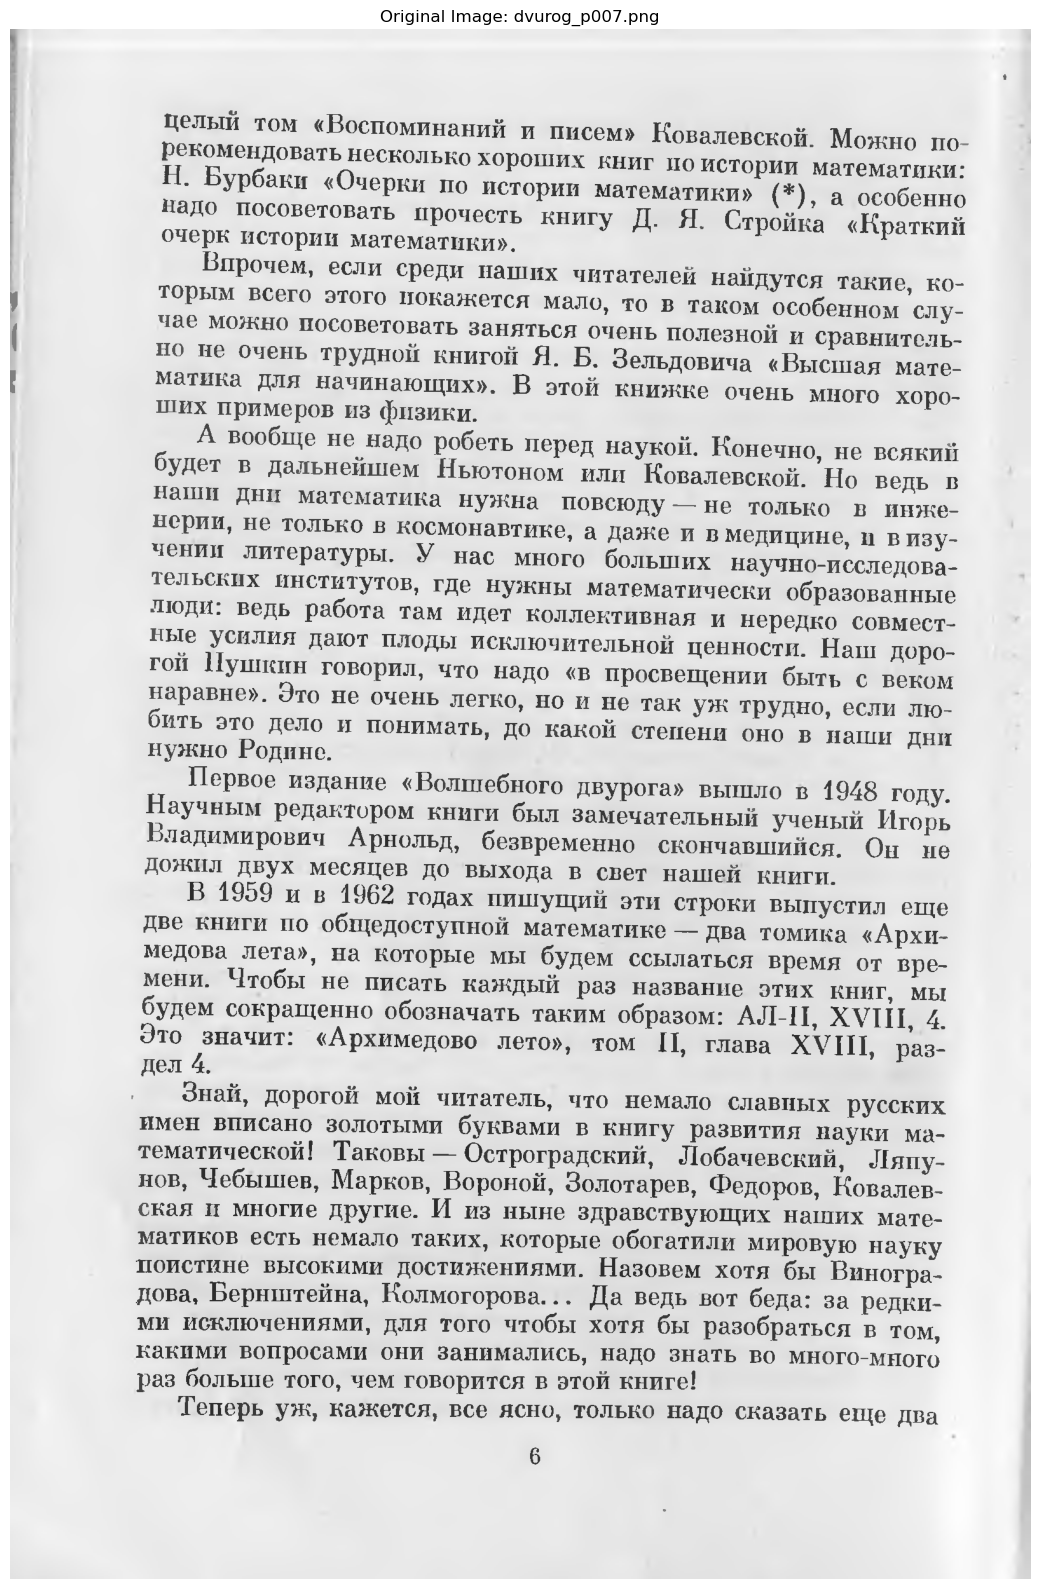

Image size: 1606 x 2439 pixels


In [3]:
# Load and display the original image
img = cv2.imread(str(input_image))
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 16))
plt.imshow(img_rgb)
plt.title(f"Original Image: {input_image.name}")
plt.axis('off')
plt.tight_layout()
plt.show()

print(f"Image size: {img.shape[1]} x {img.shape[0]} pixels")

## Step 2: Run Layout Analysis

Detect different content types in the image.

In [4]:
print("Running layout analysis...")
layout_boxes = analyze_layout(str(input_image))

# Sort boxes by y position (top to bottom), then x position (left to right)
layout_boxes_sorted = sorted(layout_boxes, key=lambda item: (item[0].bounds[1], item[0].bounds[0]))

print(f"\n✓ Detected {len(layout_boxes_sorted)} layout boxes:\n")
for i, (box_geom, box_type) in enumerate(layout_boxes_sorted, 1):
    bounds = box_geom.bounds
    print(f"{i:2d}. {box_type:20s}: ({bounds[0]:6.1f}, {bounds[1]:6.1f}) -> ({bounds[2]:6.1f}, {bounds[3]:6.1f})")

Running layout analysis...

image 1/1 /home/sergey/code/python/segmentation/images/dvurog_p007.png: 1024x704 8 plain texts, 1 abandon, 968.4ms
Speed: 3.5ms preprocess, 968.4ms inference, 0.6ms postprocess per image at shape (1, 3, 1024, 704)

✓ Detected 8 layout boxes:

 1. plain text          : ( 234.7,  126.0) -> (1509.8,  358.4)
 2. plain text          : ( 225.5,  361.4) -> (1503.6,  628.0)
 3. plain text          : ( 218.5,  629.5) -> (1494.8, 1161.6)
 4. plain text          : ( 210.2, 1167.3) -> (1482.5, 1348.1)
 5. plain text          : ( 204.1, 1349.8) -> (1477.7, 1656.5)
 6. plain text          : ( 197.6, 1659.5) -> (1473.7, 2148.2)
 7. plain text          : ( 258.5, 2154.3) -> (1464.5, 2197.6)
 8. abandon             : ( 813.5, 2230.1) -> ( 836.9, 2260.4)


## Step 3: Visualize Layout Detection

Show detected boxes overlaid on the original image.

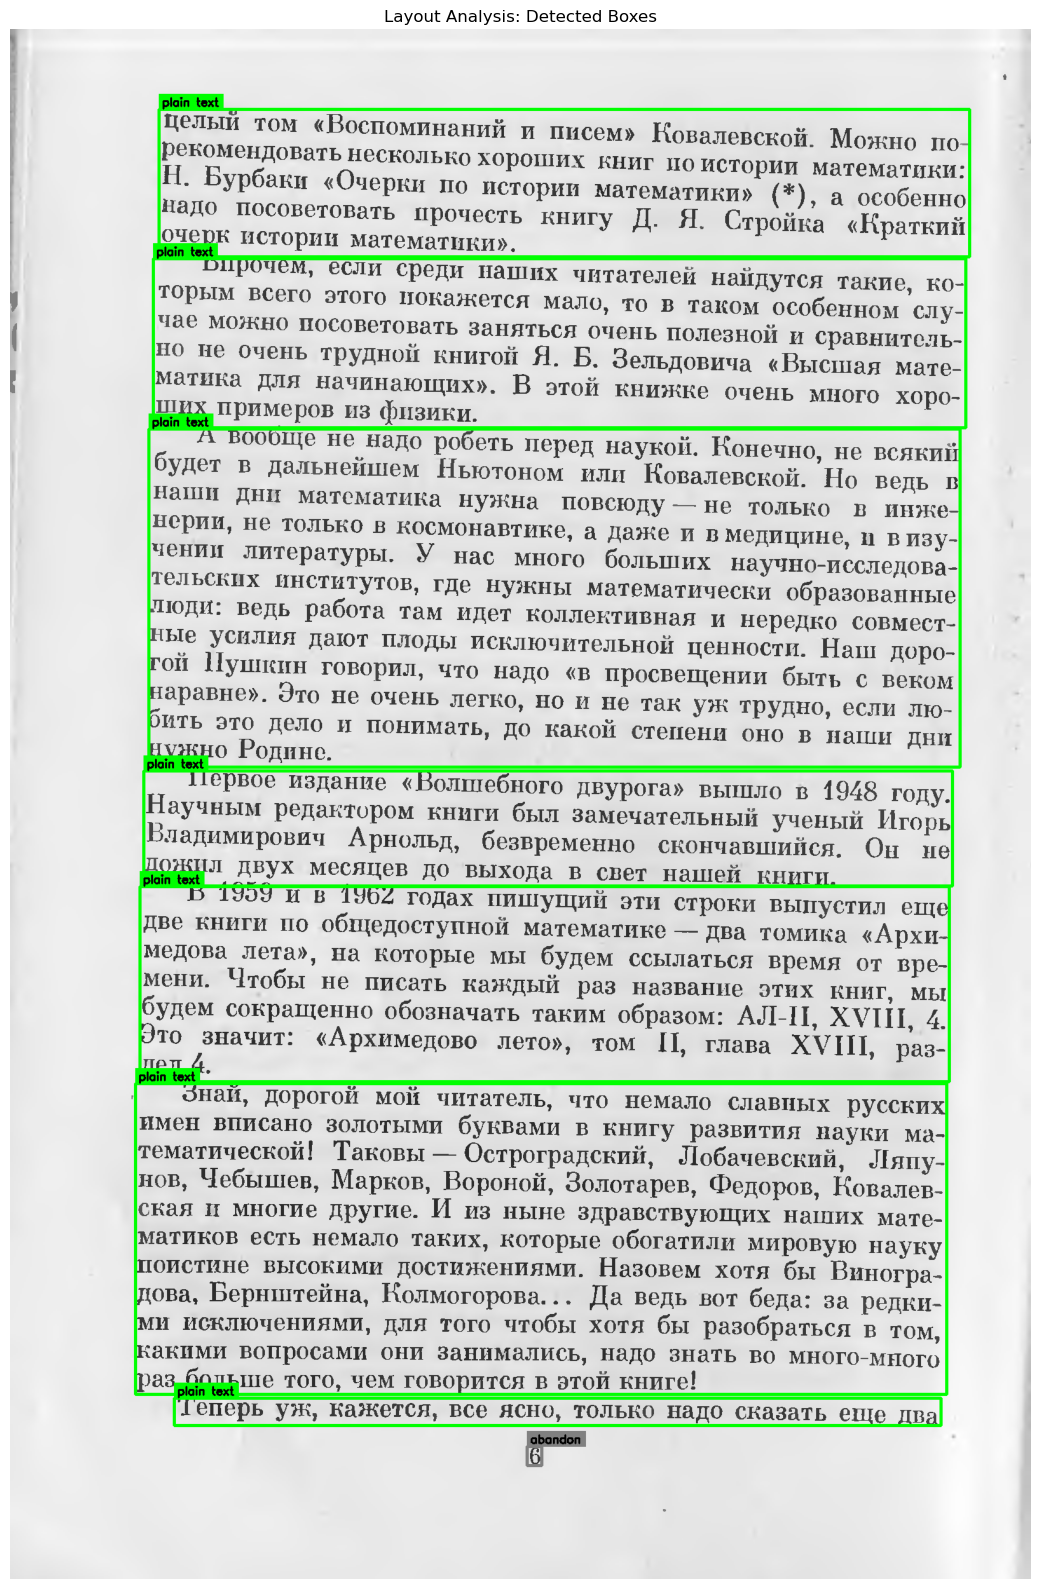


Color Legend:
  plain text                    : RGB(0, 255, 0)
  abandon                       : RGB(128, 128, 128)


In [5]:
# Create a copy of the image for visualization
img_with_boxes = img_rgb.copy()

# Define colors for different box types
type_colors = {
    'title': (255, 0, 0),              # Red
    'plain text': (0, 255, 0),         # Green
    'abandon': (128, 128, 128),        # Gray
    'figure': (255, 165, 0),           # Orange
    'figure_caption': (255, 200, 0),   # Light Orange
    'figure_and_caption': (255, 140, 0), # Dark Orange
    'table': (0, 255, 255),            # Cyan
    'table_caption': (0, 200, 255),    # Light Cyan
    'table_footnote': (0, 150, 255),   # Medium Cyan
    'isolate_formula': (255, 0, 255),  # Magenta
    'formula_caption': (200, 0, 255),  # Light Magenta
    'isolate_formula_and_caption': (180, 0, 255),  # Medium Magenta
}

# Draw boxes
for box_geom, box_type in layout_boxes_sorted:
    bounds = box_geom.bounds
    xmin, ymin, xmax, ymax = int(bounds[0]), int(bounds[1]), int(bounds[2]), int(bounds[3])
    
    color = type_colors.get(box_type, (255, 255, 255))
    
    # Draw rectangle
    cv2.rectangle(img_with_boxes, (xmin, ymin), (xmax, ymax), color, 3)
    
    # Add label
    label = box_type
    label_size = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.6, 2)[0]
    cv2.rectangle(img_with_boxes, 
                  (xmin, ymin - label_size[1] - 10), 
                  (xmin + label_size[0] + 10, ymin), 
                  color, -1)
    cv2.putText(img_with_boxes, label, (xmin + 5, ymin - 5), 
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 0), 2)

plt.figure(figsize=(12, 16))
plt.imshow(img_with_boxes)
plt.title("Layout Analysis: Detected Boxes")
plt.axis('off')
plt.tight_layout()
plt.show()

# Show legend
print("\nColor Legend:")
for box_type, color in type_colors.items():
    if any(bt == box_type for _, bt in layout_boxes_sorted):
        print(f"  {box_type:30s}: RGB{color}")

## Step 3a: Visualize Detected Text Lines

For plain text boxes, we detect text lines by finding leftmost and rightmost points. This visualization shows:
- **Blue circles**: Leftmost points of each line
- **Yellow circles**: Rightmost points of each line
- **Colored lines**: Detected text baselines
- **Gray rectangles**: Individual detected words

Detecting text lines in plain text regions...
Detected 49 text lines


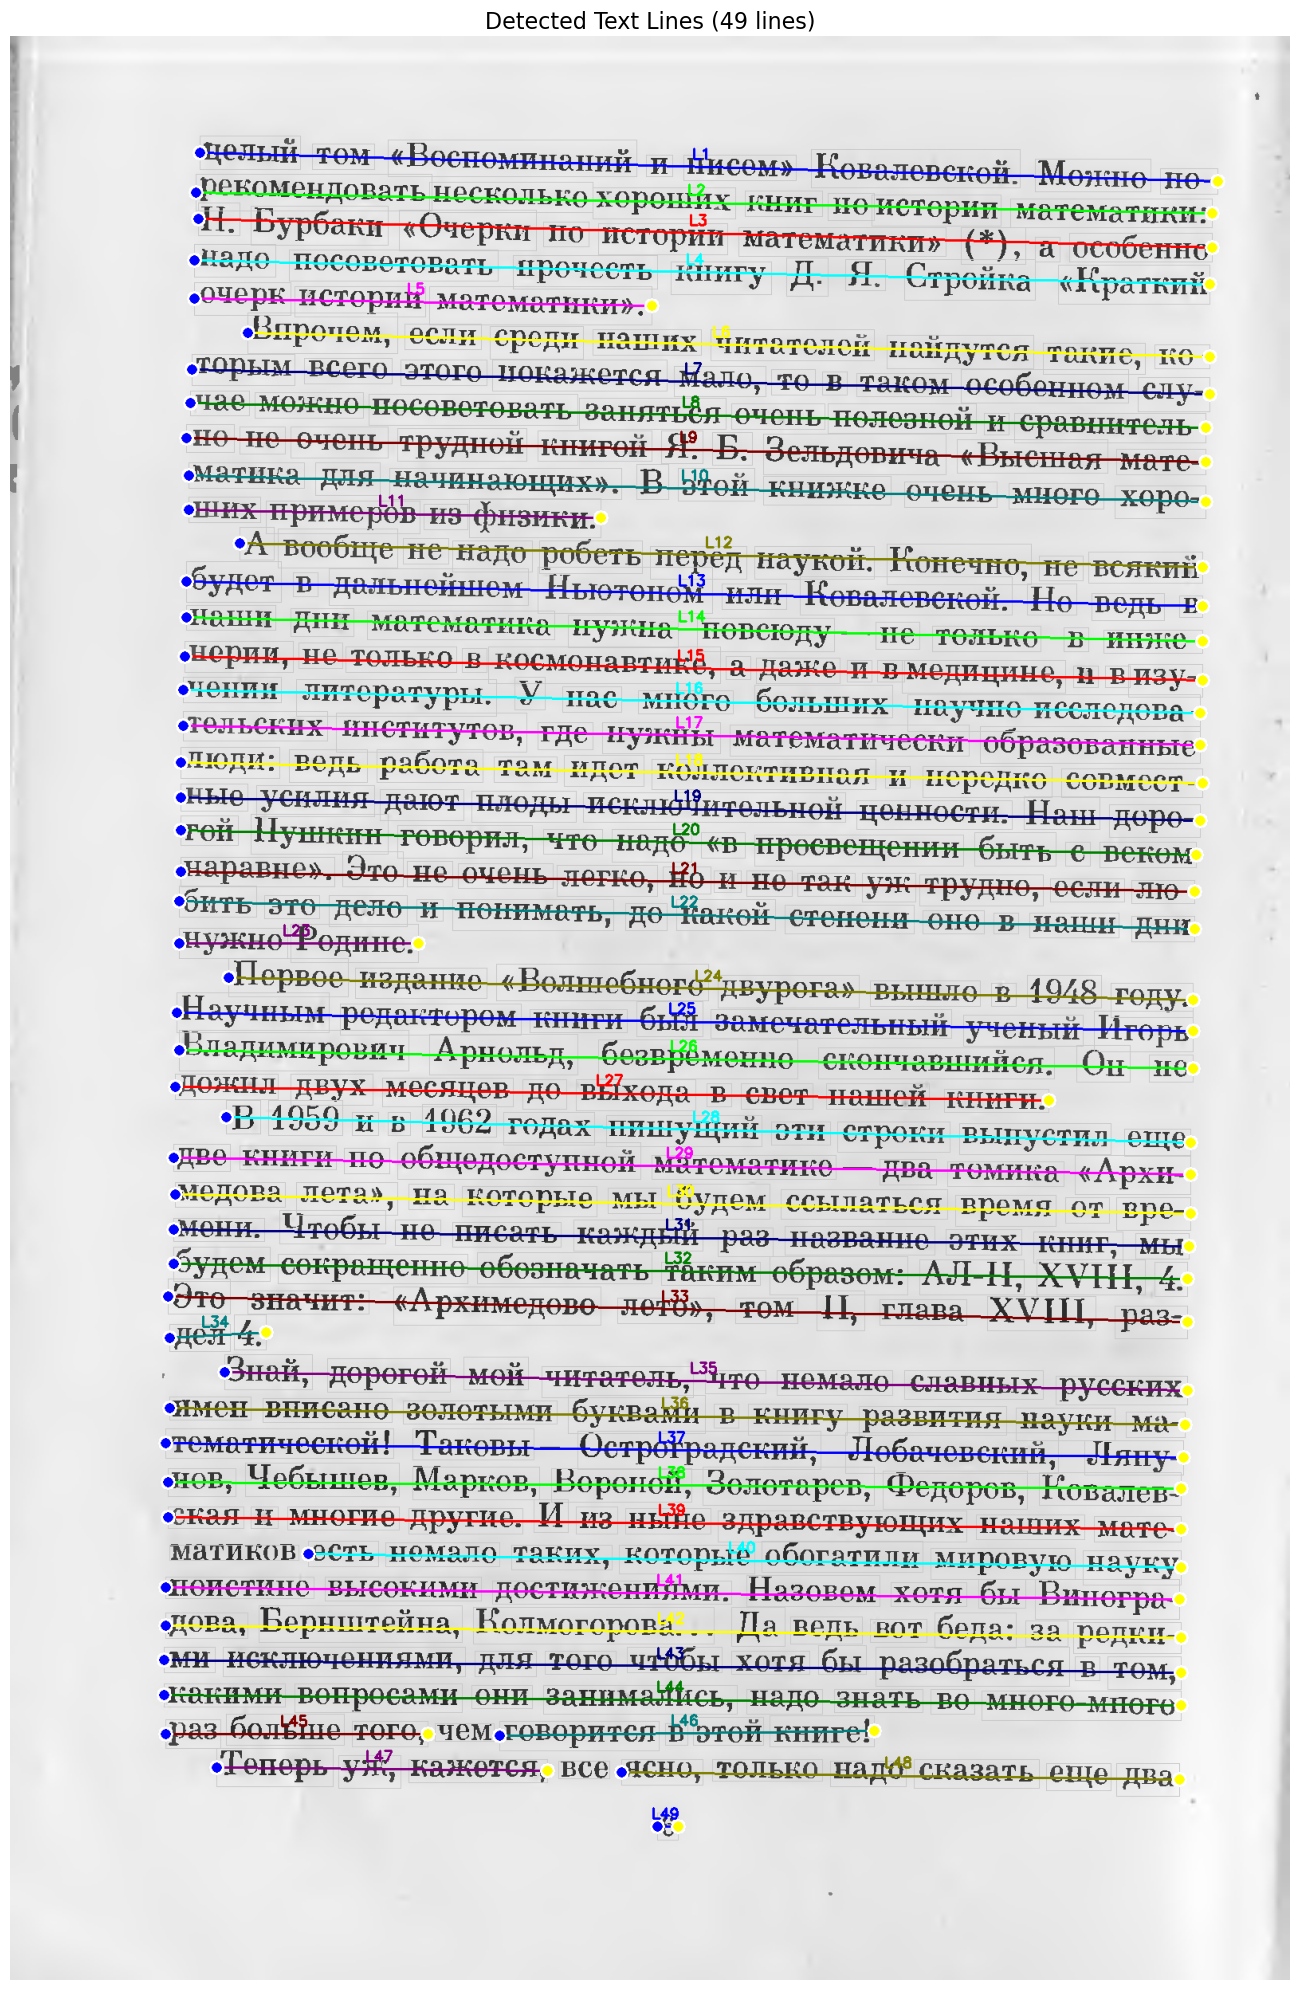


Line details:
  Line  1: left=( 238, 146)  right=(1515, 182)  width=1277px
  Line  2: left=( 233, 196)  right=(1508, 222)  width=1275px
  Line  3: left=( 236, 229)  right=(1508, 265)  width=1272px
  Line  4: left=( 231, 281)  right=(1505, 311)  width=1274px
  Line  5: left=( 231, 329)  right=( 805, 338)  width= 574px
  Line  6: left=( 298, 372)  right=(1505, 402)  width=1207px
  Line  7: left=( 228, 418)  right=(1505, 449)  width=1277px
  Line  8: left=( 226, 460)  right=(1500, 491)  width=1274px
  Line  9: left=( 221, 504)  right=(1500, 534)  width=1279px
  Line 10: left=( 224, 551)  right=(1500, 584)  width=1276px
  Line 11: left=( 224, 594)  right=( 741, 604)  width= 517px
  Line 12: left=( 288, 636)  right=(1496, 666)  width=1208px
  Line 13: left=( 221, 684)  right=(1496, 715)  width=1275px
  Line 14: left=( 221, 729)  right=(1496, 759)  width=1275px
  Line 15: left=( 219, 778)  right=(1496, 808)  width=1277px
  Line 16: left=( 217, 820)  right=(1493, 849)  width=1276px
  Line 17

In [6]:
# Import additional modules for line detection
from ocr_reflow.main import margins
from doctr.models import detection_predictor
from doctr.io import DocumentFile

# Process plain text boxes to detect lines
print("Detecting text lines in plain text regions...")

original_img = cv2.imread(input_image)

# Create visualization
line_vis_img = original_img.copy()

# Colors for different lines
line_colors = [
    (255, 0, 0), (0, 255, 0), (0, 0, 255), (255, 255, 0), (255, 0, 255), (0, 255, 255),
    (128, 0, 0), (0, 128, 0), (0, 0, 128), (128, 128, 0), (128, 0, 128), (0, 128, 128)
]

# Run word detection
model = detection_predictor(pretrained=True)
docs = DocumentFile.from_images([input_image])
result = model(docs)
words = result[0]["words"]

# Convert normalized coordinates to absolute
img_h, img_w = original_img.shape[:2]
words[:, 0] = (words[:, 0] * img_w).astype(np.int32)
words[:, 1] = (words[:, 1] * img_h).astype(np.int32) + 2
words[:, 2] = (words[:, 2] * img_w).astype(np.int32)
words[:, 3] = (words[:, 3] * img_h).astype(np.int32) - 2
words = words.astype(np.int32)

# Draw all detected words in light gray
for xmin, ymin, xmax, ymax, _ in words:
    cv2.rectangle(line_vis_img, (xmin, ymin), (xmax, ymax), (200, 200, 200), 1)

# Detect margins (lines)
left_margins, right_margins = margins(words)

print(f"Detected {len(left_margins)} text lines")

# Draw detected lines
for i, (l, r) in enumerate(zip(left_margins, right_margins)):
    color = line_colors[i % len(line_colors)]
    
    # Draw line connecting left and right margins
    cv2.line(line_vis_img, l, r, color, 2)
    
    # Draw circles at leftmost point (blue)
    cv2.circle(line_vis_img, l, 8, (255, 0, 0), -1)
    cv2.circle(line_vis_img, l, 8, (255, 255, 255), 2)
    
    # Draw circles at rightmost point (yellow)
    cv2.circle(line_vis_img, r, 8, (0, 255, 255), -1)
    cv2.circle(line_vis_img, r, 8, (255, 255, 255), 2)
    
    # Add line number label
    mid_x = (l[0] + r[0]) // 2
    mid_y = (l[1] + r[1]) // 2
    cv2.putText(line_vis_img, f"L{i+1}", (mid_x - 20, mid_y - 10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)

# Display
plt.figure(figsize=(15, 20))
plt.imshow(cv2.cvtColor(line_vis_img, cv2.COLOR_BGR2RGB))
plt.title(f'Detected Text Lines ({len(left_margins)} lines)', fontsize=16)
plt.axis('off')
plt.tight_layout()
plt.show()

# Print line details
print(f"\nLine details:")
for i, (l, r) in enumerate(zip(left_margins, right_margins)):
    width = r[0] - l[0]
    print(f"  Line {i+1:2d}: left=({l[0]:4d}, {l[1]:3d})  right=({r[0]:4d}, {r[1]:3d})  width={width:4d}px")

## Step 3a: Visualize Detected Text Lines

For plain text boxes, we detect text lines by finding leftmost and rightmost points. This visualization shows:
- **Blue circles**: Leftmost points of each line
- **Yellow circles**: Rightmost points of each line
- **Colored lines**: Detected text baselines
- **Gray rectangles**: Individual detected words

Detecting text lines in plain text regions...
Detected 49 text lines


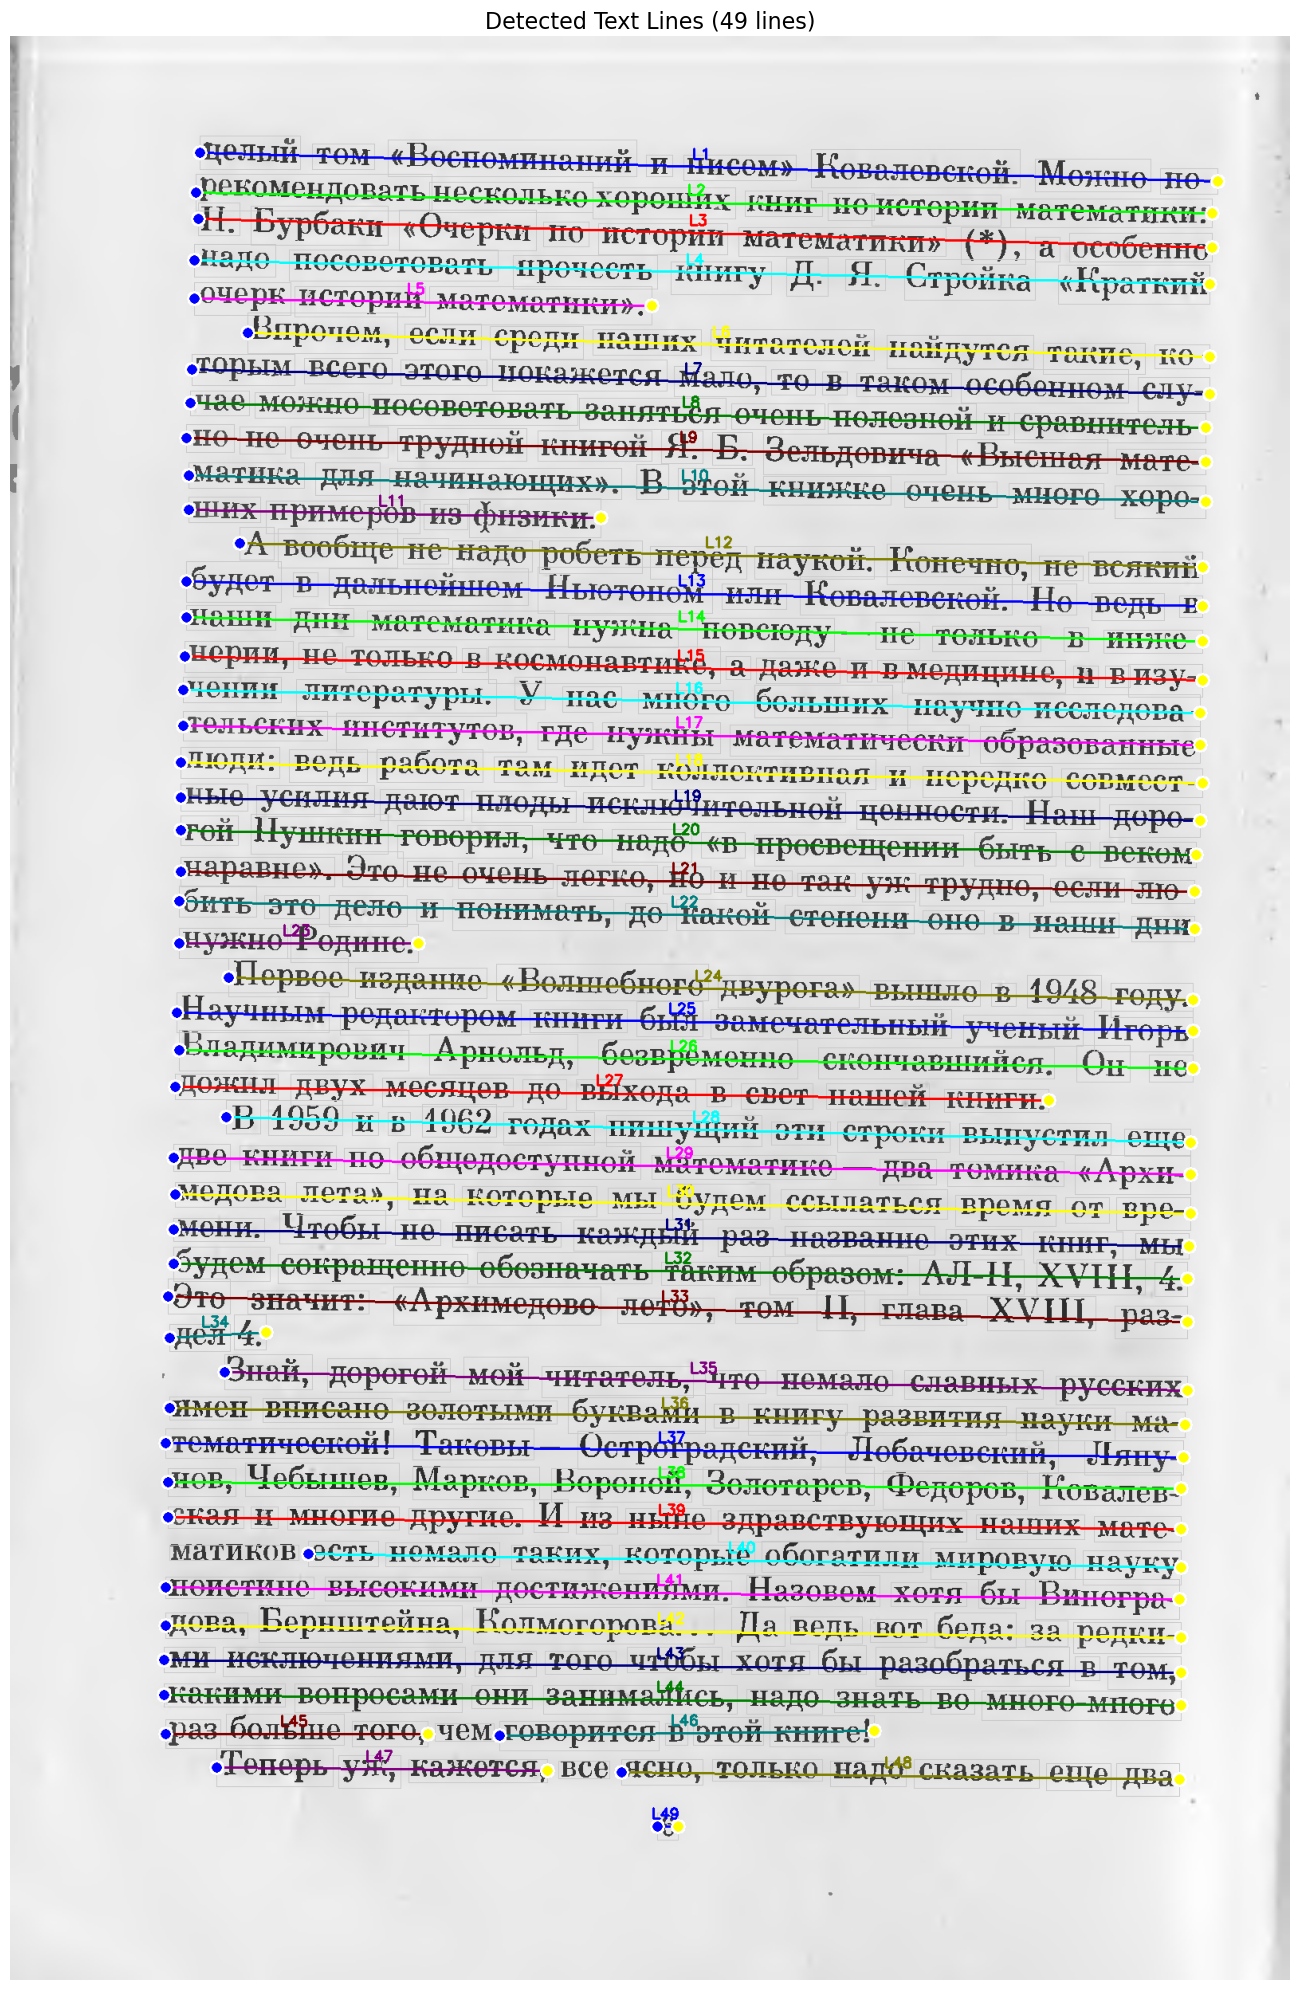


Line details:
  Line  1: left=( 238, 146)  right=(1515, 182)  width=1277px
  Line  2: left=( 233, 196)  right=(1508, 222)  width=1275px
  Line  3: left=( 236, 229)  right=(1508, 265)  width=1272px
  Line  4: left=( 231, 281)  right=(1505, 311)  width=1274px
  Line  5: left=( 231, 329)  right=( 805, 338)  width= 574px
  Line  6: left=( 298, 372)  right=(1505, 402)  width=1207px
  Line  7: left=( 228, 418)  right=(1505, 449)  width=1277px
  Line  8: left=( 226, 460)  right=(1500, 491)  width=1274px
  Line  9: left=( 221, 504)  right=(1500, 534)  width=1279px
  Line 10: left=( 224, 551)  right=(1500, 584)  width=1276px
  Line 11: left=( 224, 594)  right=( 741, 604)  width= 517px
  Line 12: left=( 288, 636)  right=(1496, 666)  width=1208px
  Line 13: left=( 221, 684)  right=(1496, 715)  width=1275px
  Line 14: left=( 221, 729)  right=(1496, 759)  width=1275px
  Line 15: left=( 219, 778)  right=(1496, 808)  width=1277px
  Line 16: left=( 217, 820)  right=(1493, 849)  width=1276px
  Line 17

In [9]:
# Import additional modules for line detection
from ocr_reflow.main import margins
from doctr.models import detection_predictor
from doctr.io import DocumentFile

# Process plain text boxes to detect lines
print("Detecting text lines in plain text regions...")

original_img = cv2.imread(input_image)

# Create visualization
line_vis_img = original_img.copy()

# Colors for different lines
line_colors = [
    (255, 0, 0), (0, 255, 0), (0, 0, 255), (255, 255, 0), (255, 0, 255), (0, 255, 255),
    (128, 0, 0), (0, 128, 0), (0, 0, 128), (128, 128, 0), (128, 0, 128), (0, 128, 128)
]

# Run word detection
model = detection_predictor(pretrained=True)
docs = DocumentFile.from_images([input_image])
result = model(docs)
words = result[0]["words"]

# Convert normalized coordinates to absolute
img_h, img_w = original_img.shape[:2]
words[:, 0] = (words[:, 0] * img_w).astype(np.int32)
words[:, 1] = (words[:, 1] * img_h).astype(np.int32) + 2
words[:, 2] = (words[:, 2] * img_w).astype(np.int32)
words[:, 3] = (words[:, 3] * img_h).astype(np.int32) - 2
words = words.astype(np.int32)

# Draw all detected words in light gray
for xmin, ymin, xmax, ymax, _ in words:
    cv2.rectangle(line_vis_img, (xmin, ymin), (xmax, ymax), (200, 200, 200), 1)

# Detect margins (lines)
left_margins, right_margins = margins(words)

print(f"Detected {len(left_margins)} text lines")

# Draw detected lines
for i, (l, r) in enumerate(zip(left_margins, right_margins)):
    color = line_colors[i % len(line_colors)]
    
    # Draw line connecting left and right margins
    cv2.line(line_vis_img, l, r, color, 2)
    
    # Draw circles at leftmost point (blue)
    cv2.circle(line_vis_img, l, 8, (255, 0, 0), -1)
    cv2.circle(line_vis_img, l, 8, (255, 255, 255), 2)
    
    # Draw circles at rightmost point (yellow)
    cv2.circle(line_vis_img, r, 8, (0, 255, 255), -1)
    cv2.circle(line_vis_img, r, 8, (255, 255, 255), 2)
    
    # Add line number label
    mid_x = (l[0] + r[0]) // 2
    mid_y = (l[1] + r[1]) // 2
    cv2.putText(line_vis_img, f"L{i+1}", (mid_x - 20, mid_y - 10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)

# Display
plt.figure(figsize=(15, 20))
plt.imshow(cv2.cvtColor(line_vis_img, cv2.COLOR_BGR2RGB))
plt.title(f'Detected Text Lines ({len(left_margins)} lines)', fontsize=16)
plt.axis('off')
plt.tight_layout()
plt.show()

# Print line details
print(f"\nLine details:")
for i, (l, r) in enumerate(zip(left_margins, right_margins)):
    width = r[0] - l[0]
    print(f"  Line {i+1:2d}: left=({l[0]:4d}, {l[1]:3d})  right=({r[0]:4d}, {r[1]:3d})  width={width:4d}px")

## Step 3a: Visualize Detected Text Lines

For plain text boxes, we detect text lines by finding leftmost and rightmost points. This visualization shows:
- **Blue circles**: Leftmost points of each line
- **Yellow circles**: Rightmost points of each line
- **Colored lines**: Detected text baselines
- **Gray rectangles**: Individual detected words

Detecting text lines in plain text regions...
Detected 49 text lines


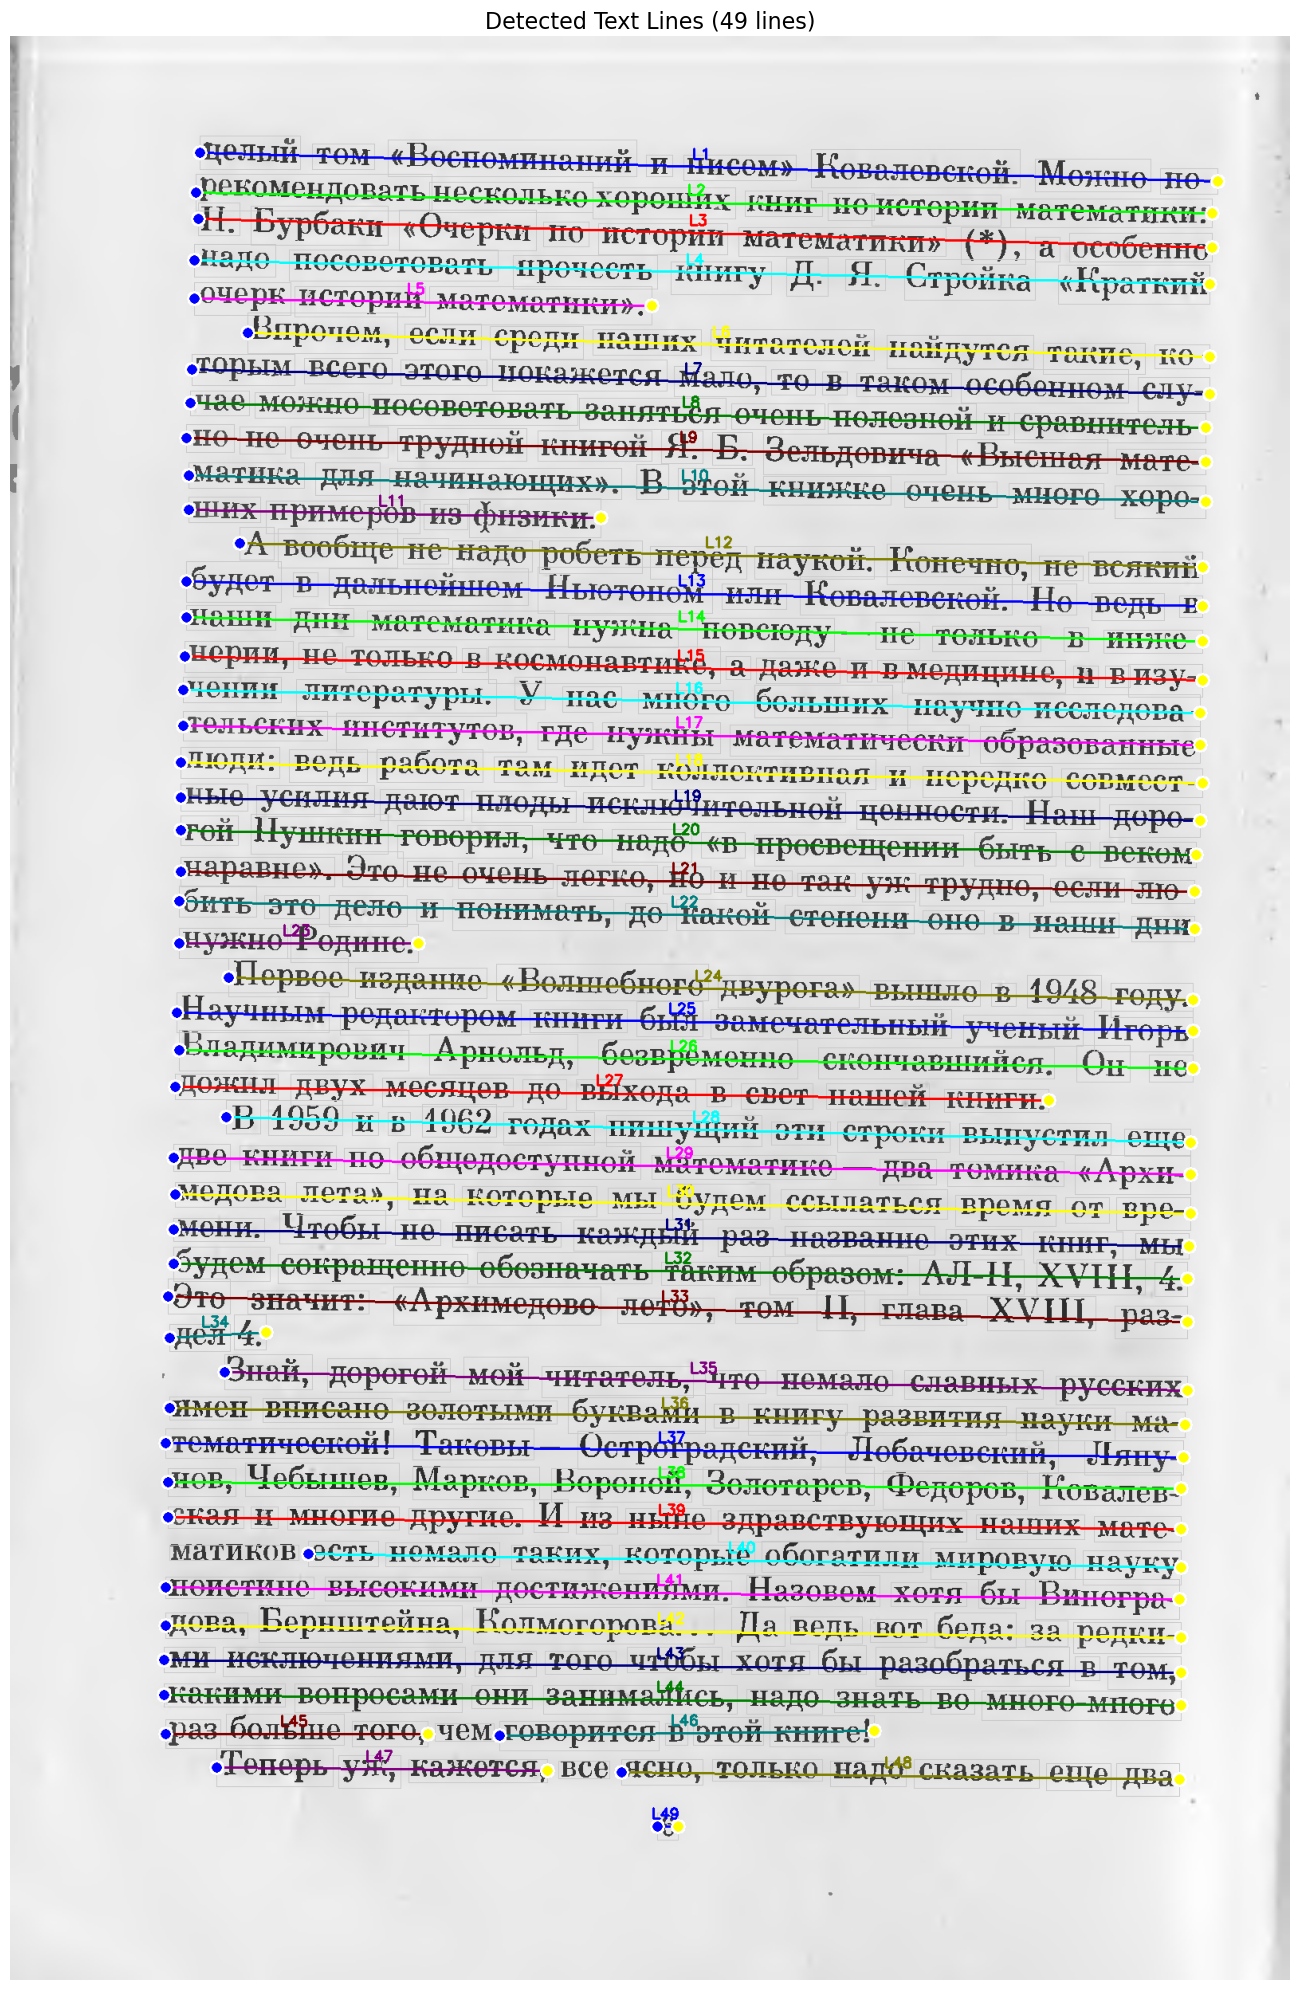


Line details:
  Line  1: left=( 238, 146)  right=(1515, 182)  width=1277px
  Line  2: left=( 233, 196)  right=(1508, 222)  width=1275px
  Line  3: left=( 236, 229)  right=(1508, 265)  width=1272px
  Line  4: left=( 231, 281)  right=(1505, 311)  width=1274px
  Line  5: left=( 231, 329)  right=( 805, 338)  width= 574px
  Line  6: left=( 298, 372)  right=(1505, 402)  width=1207px
  Line  7: left=( 228, 418)  right=(1505, 449)  width=1277px
  Line  8: left=( 226, 460)  right=(1500, 491)  width=1274px
  Line  9: left=( 221, 504)  right=(1500, 534)  width=1279px
  Line 10: left=( 224, 551)  right=(1500, 584)  width=1276px
  Line 11: left=( 224, 594)  right=( 741, 604)  width= 517px
  Line 12: left=( 288, 636)  right=(1496, 666)  width=1208px
  Line 13: left=( 221, 684)  right=(1496, 715)  width=1275px
  Line 14: left=( 221, 729)  right=(1496, 759)  width=1275px
  Line 15: left=( 219, 778)  right=(1496, 808)  width=1277px
  Line 16: left=( 217, 820)  right=(1493, 849)  width=1276px
  Line 17

In [11]:
# Import additional modules for line detection
from ocr_reflow.main import margins
from doctr.models import detection_predictor
from doctr.io import DocumentFile

# Process plain text boxes to detect lines
print("Detecting text lines in plain text regions...")

# Create visualization
line_vis_img = original_img.copy()

# Colors for different lines
line_colors = [
    (255, 0, 0), (0, 255, 0), (0, 0, 255), (255, 255, 0), (255, 0, 255), (0, 255, 255),
    (128, 0, 0), (0, 128, 0), (0, 0, 128), (128, 128, 0), (128, 0, 128), (0, 128, 128)
]

# Run word detection
model = detection_predictor(pretrained=True)
docs = DocumentFile.from_images([input_image])
result = model(docs)
words = result[0]["words"]

# Convert normalized coordinates to absolute
img_h, img_w = original_img.shape[:2]
words[:, 0] = (words[:, 0] * img_w).astype(np.int32)
words[:, 1] = (words[:, 1] * img_h).astype(np.int32) + 2
words[:, 2] = (words[:, 2] * img_w).astype(np.int32)
words[:, 3] = (words[:, 3] * img_h).astype(np.int32) - 2
words = words.astype(np.int32)

# Draw all detected words in light gray
for xmin, ymin, xmax, ymax, _ in words:
    cv2.rectangle(line_vis_img, (xmin, ymin), (xmax, ymax), (200, 200, 200), 1)

# Detect margins (lines)
left_margins, right_margins = margins(words)

print(f"Detected {len(left_margins)} text lines")

# Draw detected lines
for i, (l, r) in enumerate(zip(left_margins, right_margins)):
    color = line_colors[i % len(line_colors)]
    
    # Draw line connecting left and right margins
    cv2.line(line_vis_img, l, r, color, 2)
    
    # Draw circles at leftmost point (blue)
    cv2.circle(line_vis_img, l, 8, (255, 0, 0), -1)
    cv2.circle(line_vis_img, l, 8, (255, 255, 255), 2)
    
    # Draw circles at rightmost point (yellow)
    cv2.circle(line_vis_img, r, 8, (0, 255, 255), -1)
    cv2.circle(line_vis_img, r, 8, (255, 255, 255), 2)
    
    # Add line number label
    mid_x = (l[0] + r[0]) // 2
    mid_y = (l[1] + r[1]) // 2
    cv2.putText(line_vis_img, f"L{i+1}", (mid_x - 20, mid_y - 10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)

# Display
plt.figure(figsize=(15, 20))
plt.imshow(cv2.cvtColor(line_vis_img, cv2.COLOR_BGR2RGB))
plt.title(f'Detected Text Lines ({len(left_margins)} lines)', fontsize=16)
plt.axis('off')
plt.tight_layout()
plt.show()

# Print line details
print(f"\nLine details:")
for i, (l, r) in enumerate(zip(left_margins, right_margins)):
    width = r[0] - l[0]
    print(f"  Line {i+1:2d}: left=({l[0]:4d}, {l[1]:3d})  right=({r[0]:4d}, {r[1]:3d})  width={width:4d}px")

## Step 4: Run Reflow with Layout Analysis

Process the document and create a reflowed page.

In [13]:
# Configure reflow parameters
zoom_factor = 2.5       # Scaling factor for non-text content (figures, formulas, etc.)
new_page_width = 2000   # Width of the new page in pixels

print(f"Running reflow with layout analysis...")
print(f"  Zoom factor: {zoom_factor}")
print(f"  New page width: {new_page_width}px\n")

reflowed_page = process_document_with_layout(
    str(input_image), 
    zoom_factor=zoom_factor, 
    new_page_width=new_page_width
)

print(f"\n✓ Reflow complete!")
print(f"  Output size: {reflowed_page.shape[1]} x {reflowed_page.shape[0]} pixels")

Running reflow with layout analysis...
  Zoom factor: 2.5
  New page width: 2000px

Detected background color (BGR): [228 228 228]
Running layout analysis...

image 1/1 /home/sergey/code/python/segmentation/images/dvurog_p007.png: 1024x704 8 plain texts, 1 abandon, 902.0ms
Speed: 3.3ms preprocess, 902.0ms inference, 0.6ms postprocess per image at shape (1, 3, 1024, 704)
Detected 8 layout boxes:
  plain text: (234.7, 126.0, 1509.8, 358.4)
  plain text: (225.5, 361.4, 1503.6, 628.0)
  plain text: (218.5, 629.5, 1494.8, 1161.6)
  plain text: (210.2, 1167.3, 1482.5, 1348.1)
  plain text: (204.1, 1349.8, 1477.7, 1656.5)
  plain text: (197.6, 1659.5, 1473.7, 2148.2)
  plain text: (258.5, 2154.3, 1464.5, 2197.6)
  abandon: (813.5, 2230.1, 836.9, 2260.4)

Processing plain text box at y=126
Detected 1 paragraphs
Paragraph starts at indices: [0]
Average first letter xmin: 4.0
Paragraph 0 starts at line 0 with indentation (xmin): 7
Average line width: 1117.6, Short line threshold: 782.31999999999

## Step 5: Display Reflowed Result

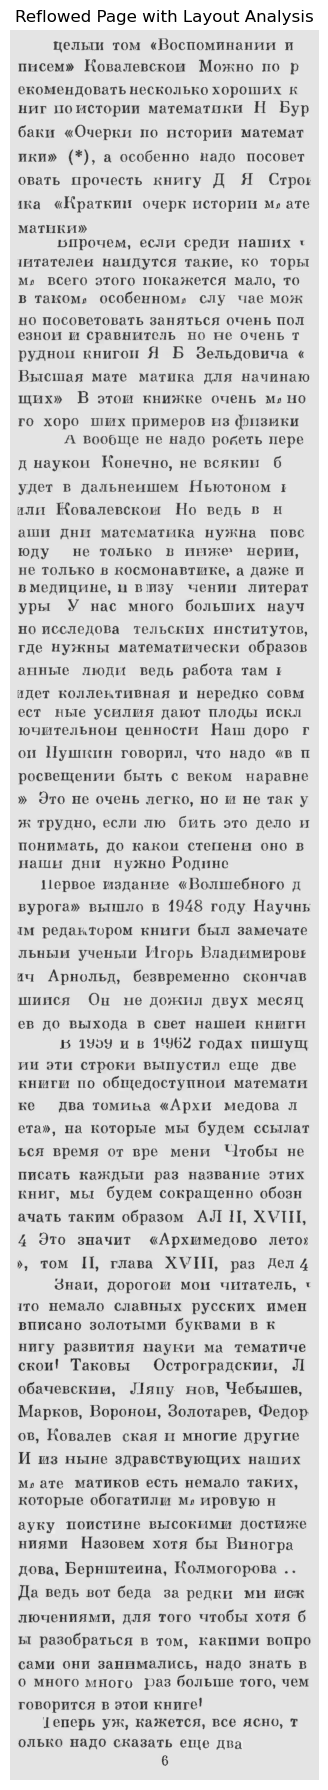

In [14]:
# Convert to RGB for display
reflowed_rgb = cv2.cvtColor(reflowed_page, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 18))
plt.imshow(reflowed_rgb)
plt.title("Reflowed Page with Layout Analysis")
plt.axis('off')
plt.tight_layout()
plt.show()

## Step 6: Side-by-Side Comparison

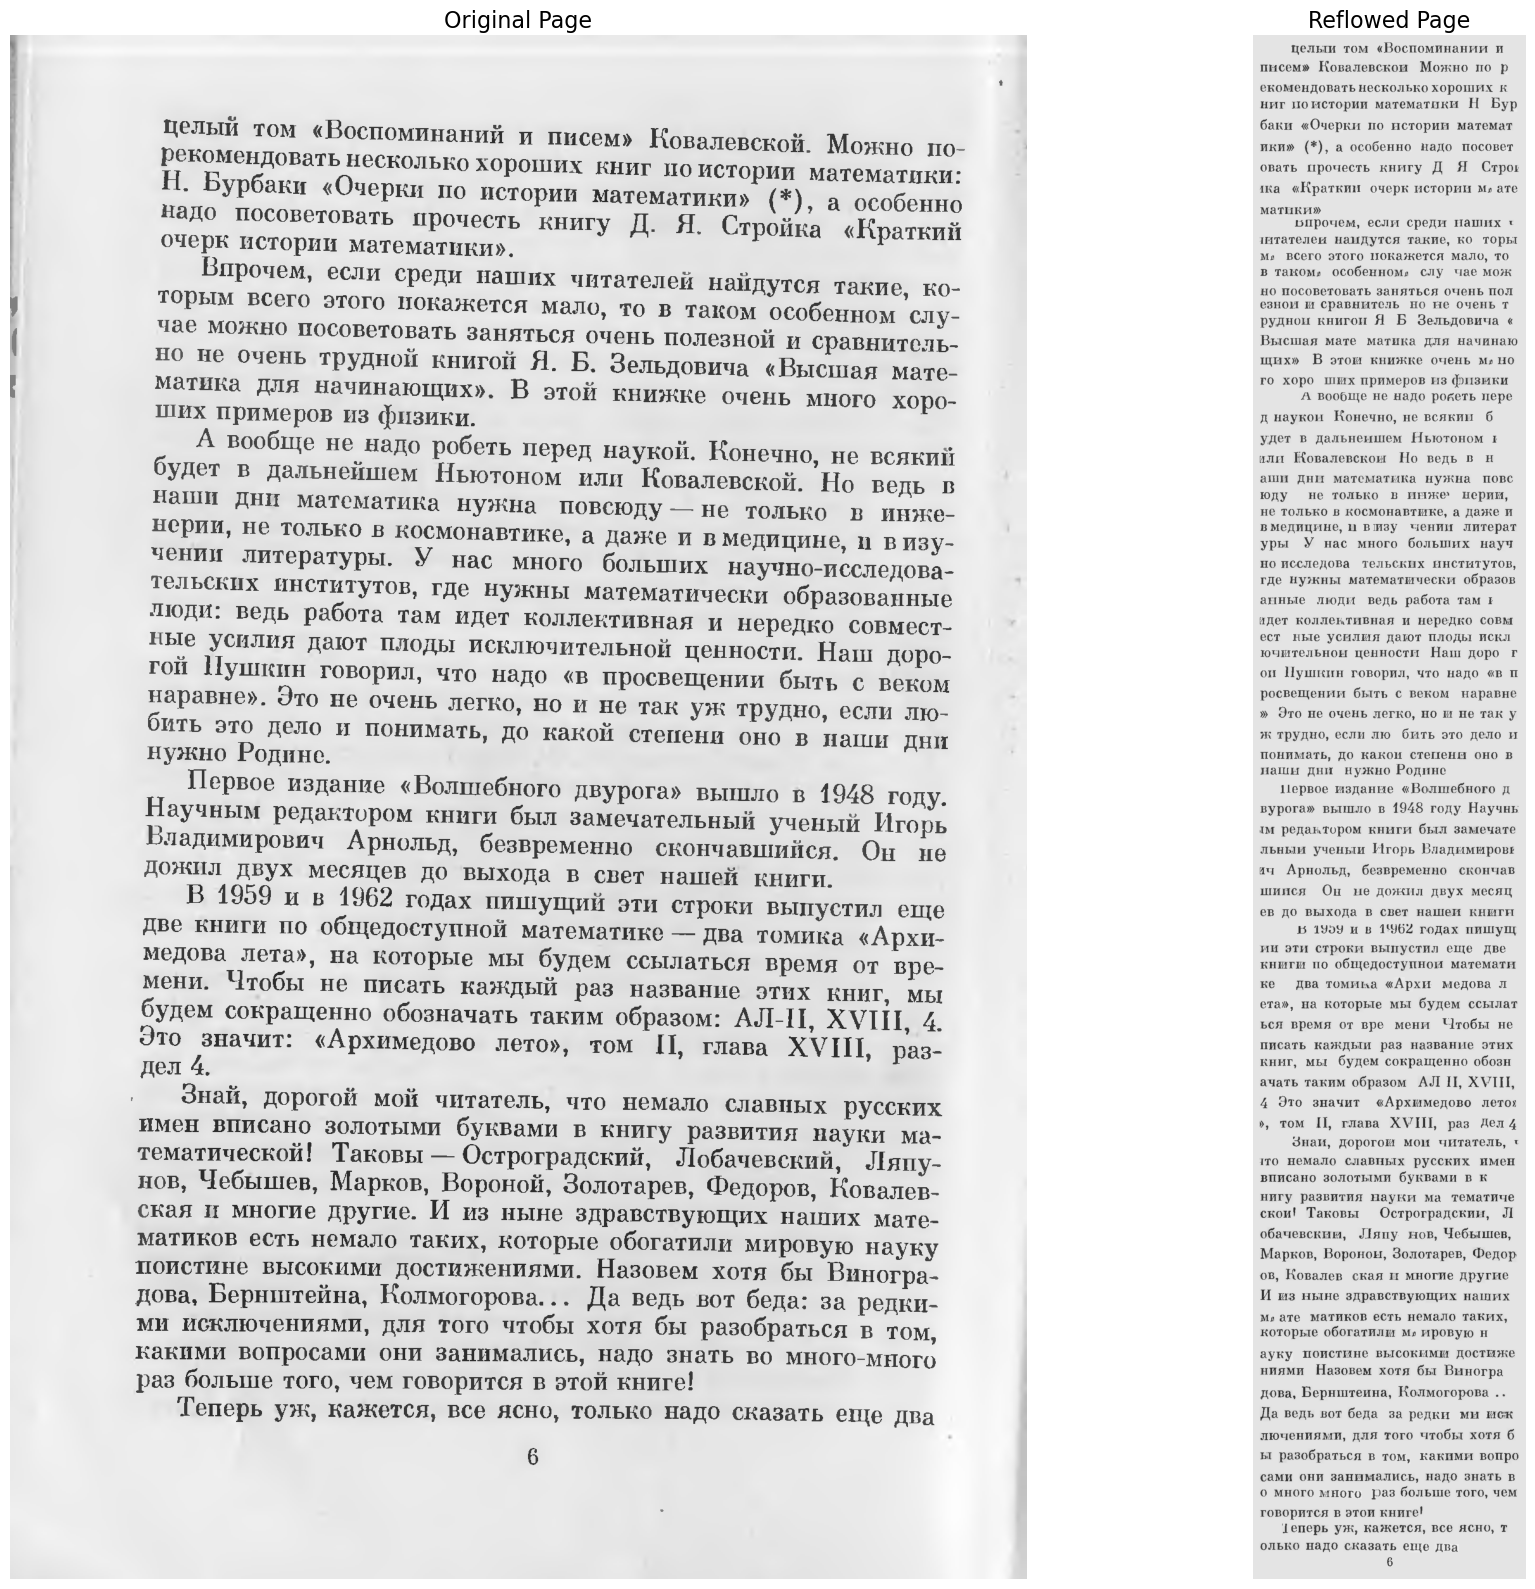

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(20, 16))

axes[0].imshow(img_rgb)
axes[0].set_title("Original Page", fontsize=16)
axes[0].axis('off')

axes[1].imshow(reflowed_rgb)
axes[1].set_title("Reflowed Page", fontsize=16)
axes[1].axis('off')

plt.tight_layout()
plt.show()

## Step 7: Save Output

In [9]:
# Save the reflowed image
output_filename = f"reflowed_{input_image.stem}.png"
output_path = Path.cwd() / output_filename

cv2.imwrite(str(output_path), reflowed_page)
print(f"✓ Saved reflowed image to: {output_path}")

# Also save the layout visualization
layout_viz_filename = f"layout_viz_{input_image.stem}.png"
layout_viz_path = Path.cwd() / layout_viz_filename

img_with_boxes_bgr = cv2.cvtColor(img_with_boxes, cv2.COLOR_RGB2BGR)
cv2.imwrite(str(layout_viz_path), img_with_boxes_bgr)
print(f"✓ Saved layout visualization to: {layout_viz_path}")

✓ Saved reflowed image to: /home/sergey/code/python/segmentation/notebooks/reflowed_dvurog_p021.png
✓ Saved layout visualization to: /home/sergey/code/python/segmentation/notebooks/layout_viz_dvurog_p021.png


## Step 8: Inspect Specific Region (Optional)

Zoom into a specific area of the reflowed page to check quality.

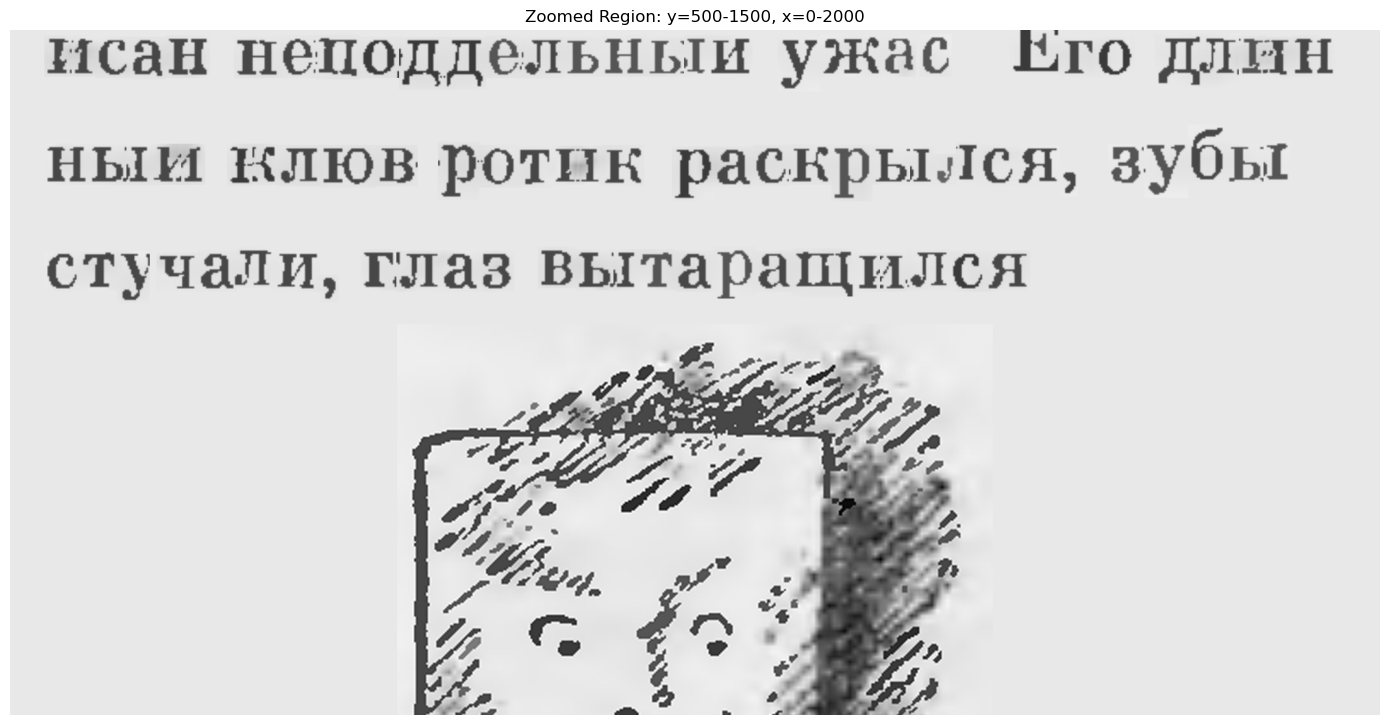

In [10]:
# Define region to inspect (y_start, y_end, x_start, x_end)
# Adjust these values to inspect different regions
y_start, y_end = 500, 1500
x_start, x_end = 0, 2000

# Ensure bounds are valid
y_end = min(y_end, reflowed_page.shape[0])
x_end = min(x_end, reflowed_page.shape[1])

region = reflowed_rgb[y_start:y_end, x_start:x_end]

plt.figure(figsize=(14, 10))
plt.imshow(region)
plt.title(f"Zoomed Region: y={y_start}-{y_end}, x={x_start}-{x_end}")
plt.axis('off')
plt.tight_layout()
plt.show()

## Experiment with Different Parameters

You can modify parameters and re-run the reflow:

Testing zoom_factor=2.0...
Detected background color (BGR): [232 232 232]
Running layout analysis...

image 1/1 /home/sergey/code/python/segmentation/images/dvurog_p021.png: 1024x672 12 plain texts, 1 abandon, 1 figure, 826.6ms
Speed: 3.3ms preprocess, 826.6ms inference, 0.6ms postprocess per image at shape (1, 3, 1024, 672)
Detected 13 layout boxes:
  plain text: (652.3, 151.7, 1504.5, 379.3)
  figure: (211.1, 169.2, 559.0, 592.6)
  plain text: (651.8, 381.6, 1500.4, 465.0)
  plain text: (218.1, 470.2, 1499.6, 828.9)
  plain text: (218.0, 831.5, 1491.9, 911.8)
  plain text: (213.6, 915.4, 1490.7, 1184.4)
  plain text: (279.1, 1185.3, 979.8, 1227.6)
  plain text: (209.2, 1232.4, 1485.7, 1361.6)
  plain text: (207.0, 1367.2, 1483.2, 1498.4)
  plain text: (208.0, 1503.1, 1481.7, 1586.0)
  plain text: (267.3, 1590.4, 1292.5, 1633.8)
  plain text: (200.8, 1637.7, 1478.7, 2213.4)
  abandon: (810.0, 2250.8, 851.1, 2283.5)

Processing plain text box at y=151
Detected 1 paragraphs
Paragraph st

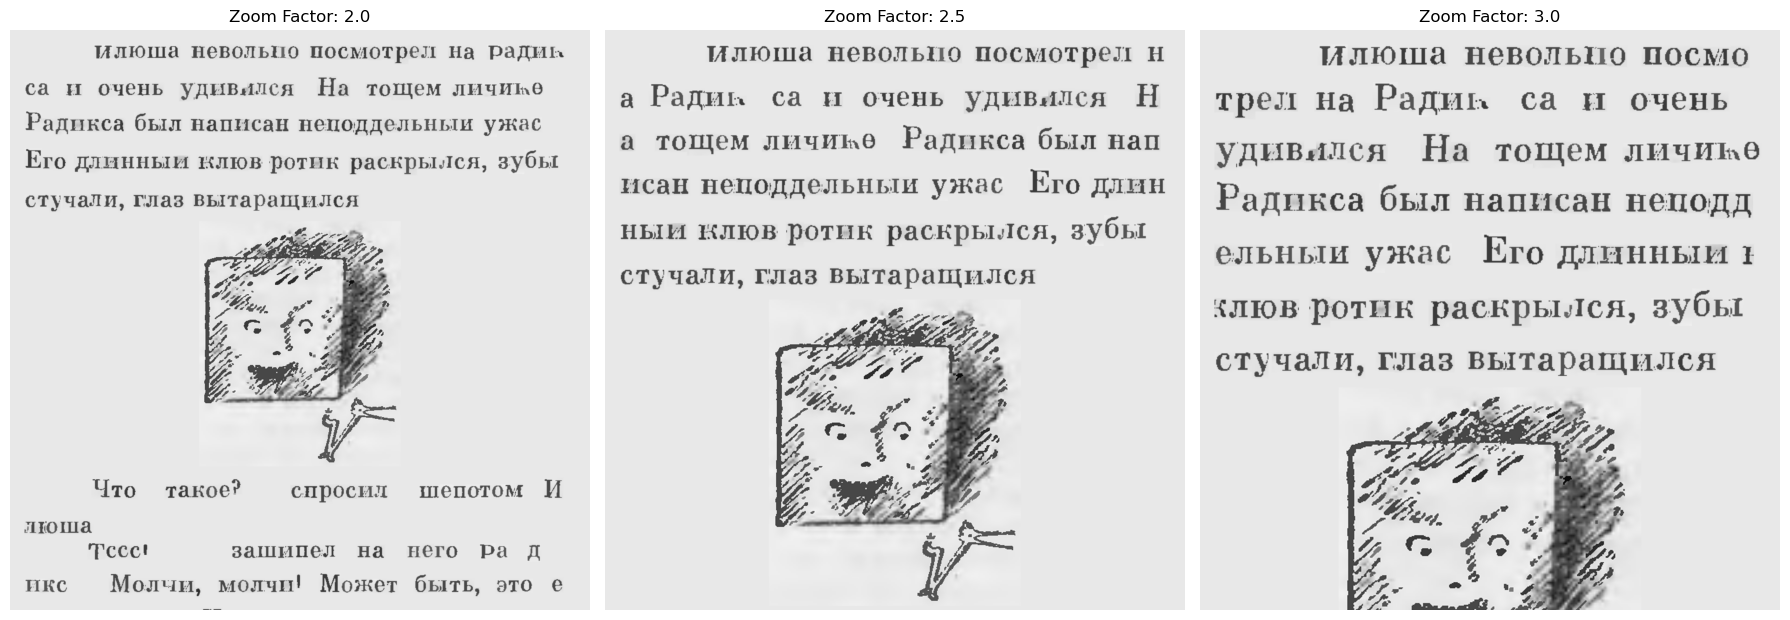

In [11]:
# Try different zoom factors
zoom_factors = [2.0, 2.5, 3.0]

fig, axes = plt.subplots(1, len(zoom_factors), figsize=(18, 12))

for i, zoom in enumerate(zoom_factors):
    print(f"Testing zoom_factor={zoom}...")
    reflowed = process_document_with_layout(
        str(input_image), 
        zoom_factor=zoom, 
        new_page_width=2000
    )
    reflowed_rgb_test = cv2.cvtColor(reflowed, cv2.COLOR_BGR2RGB)
    
    # Show only top portion for comparison
    axes[i].imshow(reflowed_rgb_test[:2000, :])
    axes[i].set_title(f"Zoom Factor: {zoom}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()

## Summary Statistics

In [12]:
# Count box types
from collections import Counter

type_counts = Counter(box_type for _, box_type in layout_boxes_sorted)

print("\nLayout Box Type Distribution:")
print("=" * 40)
for box_type, count in sorted(type_counts.items()):
    print(f"{box_type:30s}: {count:2d}")
print("=" * 40)
print(f"{'Total':30s}: {len(layout_boxes_sorted):2d}")

# Image size comparison
print(f"\nImage Size Comparison:")
print("=" * 40)
print(f"Original: {img.shape[1]:4d} x {img.shape[0]:4d} px")
print(f"Reflowed: {reflowed_page.shape[1]:4d} x {reflowed_page.shape[0]:4d} px")
print(f"Height change: {reflowed_page.shape[0] / img.shape[0]:.2f}x")


Layout Box Type Distribution:
abandon                       :  1
figure                        :  1
plain text                    : 11
Total                         : 13

Image Size Comparison:
Original: 1637 x 2495 px
Reflowed: 2000 x 11233 px
Height change: 4.50x
